In [1]:
import pandas as pd
import numpy as np
from pyMyriad import *
from pyMyriad.tabular import flatten

In [2]:
df = pd.DataFrame({
  "id": np.arange(1000),
  "Gender": np.random.choice(["M", "F"], 1000),
  "Age": np.random.randint(18, 70, 1000),
  "Income": np.random.normal(50000, 15000, 1000),
  "Country": np.random.choice(["Benin", "Albania"], 1000),
  "Education": np.random.normal(0, 1, 1000),
  "Employed": np.random.choice([0, 1], 1000)
})

In [6]:
mfun = lambda df: np.mean(df.Income)
nfun = lambda df: np.std(df.Income)
efun = lambda df: np.mean(df.Education)
benin_fun =  lambda df: df.Country == 'Benin'
age_40 = lambda df: df.Age > 40
age_60 = lambda df: df.Age > 60

atree = AnalysisTree()\
  .split_by("df.Gender")\
  .summarize_by(m = mfun, n = nfun)\
  .split_by(label = "Benin Y/N", expr = benin_fun)\
  .split_by(label = "Age Group", age40 = age_40, age60 = age_60)\
  .analyze_by(m = mfun, n = nfun, label = "Income analysis")\
  .analyze_by(m = efun, label = "Education analysis")\
  .split_at_root_by("df.Country")

res = atree.run(df)


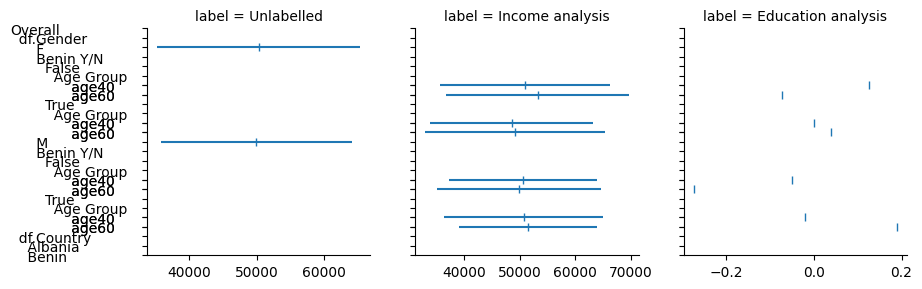

In [13]:
from pyMyriad.tabular import flatten_data
rr = flatten(res)

forest_plot(res, x = "m", x_err="n")
